In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("GPU available: ", torch.cuda.is_available())

save_dir = "Data"

GPU available:  True


In [2]:
class MyDataset(Dataset):
    def __init__(self, data, target, transform=None, target_transform=None):
        self.data = data
        self.target = target
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        x = self.data[index]
        if self.transform:
            x = self.transform(x)

        y = self.target[index]
        if self.target_transform:
            y = self.target_transform(y)

        return x, y

# Download Image dataset

In [3]:
try:
    img = np.load(os.path.join(save_dir, 'Img.npy'))
    print("Image dataset loaded.")
except Exception as e:
    from sklearn.datasets import fetch_lfw_people
    min_faces_per_person = 30
    faces = fetch_lfw_people(min_faces_per_person=min_faces_per_person)
    print("Image dataset loaded from sklearn.")
    img = faces.images
    np.save(os.path.join(save_dir, 'Img.npy'), img)
    print("Image dataset saved.")

Image dataset loaded.


# Transform image into grayscale value matrix

In [4]:
np.shape(img[1])

(62, 47)

In [5]:
def grayscale(image):
    X, Y = np.shape(image)

    m = image.min()
    M = image.max()

    for i in range(X):
        for j in range(Y):  
            image[i, j] = (image[i, j] * 255) / (M) if M > 0 else 0

    return image

img_grayscale = np.array([grayscale(image) for image in img])

# Add noise to the images

In [6]:
def add_noise(image, noise_factor=0.5):
    noise = np.random.randn(*image.shape) * noise_factor
    noisy_image = image + noise
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

img_noisy = np.zeros_like(img_grayscale)

for i in range(len(img_grayscale)):
    img_noisy[i] = add_noise(img_grayscale[i], noise_factor=10)

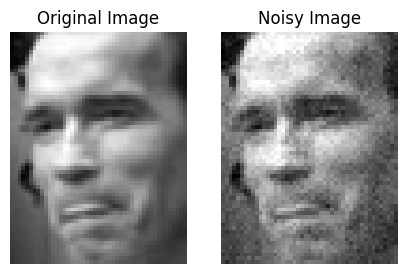

In [7]:
plt.figure(figsize=(5, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_grayscale[1], cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Noisy Image")
plt.imshow(img_noisy[1], cmap='gray')
plt.axis('off')

plt.show()

# Convolutional Neural Network

In [8]:
# Transform function to add channel dimension and normalize
def add_channel(image):
    return torch.FloatTensor(image).unsqueeze(0) / 255.0

# Split the dataset into training and testing sets
train_data = img_noisy[:1500]
train_targets = img_grayscale[:1500]

test_data = img_noisy[1500:]
test_targets = img_grayscale[1500:]

# Create datasets and dataloaders with transforms
train_dataset = MyDataset(train_data, train_targets, 
                         transform=add_channel, 
                         target_transform=add_channel)
test_dataset = MyDataset(test_data, test_targets,
                        transform=add_channel,
                        target_transform=add_channel)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [9]:
# # Training function
# def train(dataloader, model, loss_fn, optimizer):
#     model.train()
#     total_loss = 0
    
#     for X, y in dataloader:
#         X, y = X.to(device), y.to(device)
        
#         # Compute prediction and loss
#         pred = model(X)
#         loss = loss_fn(pred, y)
        
#         # Backpropagation
#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
        
#         total_loss += loss.item()
    
#     avg_loss = total_loss / len(dataloader)
#     return avg_loss

# # Simple working CNN backbone for denoising (no pooling - preserves dimensions)
# cnn_backbone = nn.Sequential(
#     # Encoder
#     nn.Conv2d(1, 16, 3, padding=1),  # 1 channel (grayscale), keep size
#     nn.ReLU(),
#     nn.Conv2d(16, 32, 3, padding=1),
#     nn.ReLU(),
#     nn.Conv2d(32, 64, 3, padding=1),
#     nn.ReLU(),
    
#     # Decoder
#     nn.Conv2d(64, 32, 3, padding=1),
#     nn.ReLU(),
#     nn.Conv2d(32, 16, 3, padding=1),
#     nn.ReLU(),
#     nn.Conv2d(16, 1, 3, padding=1),  # Back to 1 channel output
# ).to(device)

# # Loss function and optimizer
# #loss_fn = nn.MSELoss()
# loss_fn = nn.L1Loss()
# optimizer = torch.optim.Adam(cnn_backbone.parameters(), lr=1e-3)

In [10]:
def train(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        
        # Predict noise
        noise = model(X)
        # Get clean image by subtracting predicted noise
        pred = X - noise
        
        # Loss between predicted clean and target clean
        loss = loss_fn(pred, y)
        
        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

# DnCNN using nn.Sequential
layers = []

# First layer: Conv(3×3,64) + ReLU
layers.append(nn.Conv2d(1, 64, kernel_size=3, padding=1))
layers.append(nn.ReLU(inplace=True))

# Middle 15 layers: Conv(3×3,64) + BN + ReLU
for _ in range(15):
    layers.append(nn.Conv2d(64, 64, kernel_size=3, padding=1))
    layers.append(nn.BatchNorm2d(64))
    layers.append(nn.ReLU(inplace=True))

# Last layer: Conv(3×3,1) - outputs noise
layers.append(nn.Conv2d(64, 1, kernel_size=3, padding=1))

cnn = nn.Sequential(*layers).to(device)

# Loss function and optimizer
loss_fn = nn.MSELoss()
# loss_fn = nn.L1Loss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

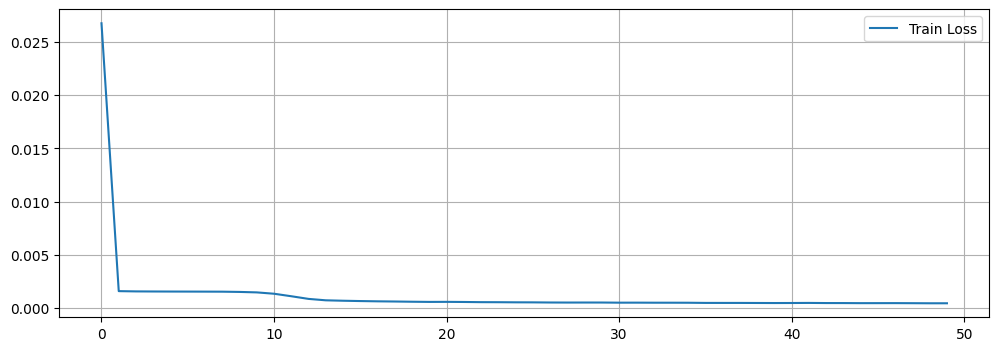

In [11]:
# Training loop (simplified - just track loss, not accuracy)
epochs = 50
train_losses = []
for t in range(epochs):
    print(f"Epoch {t+1}/{epochs}", end="\r")
    train_loss = train(train_loader, cnn, loss_fn, optimizer)
    train_losses.append(train_loss)

plt.figure(figsize=(12, 4))
plt.plot(train_losses, label='Train Loss')
plt.legend()
plt.grid()
plt.show()

# Test the final CNN

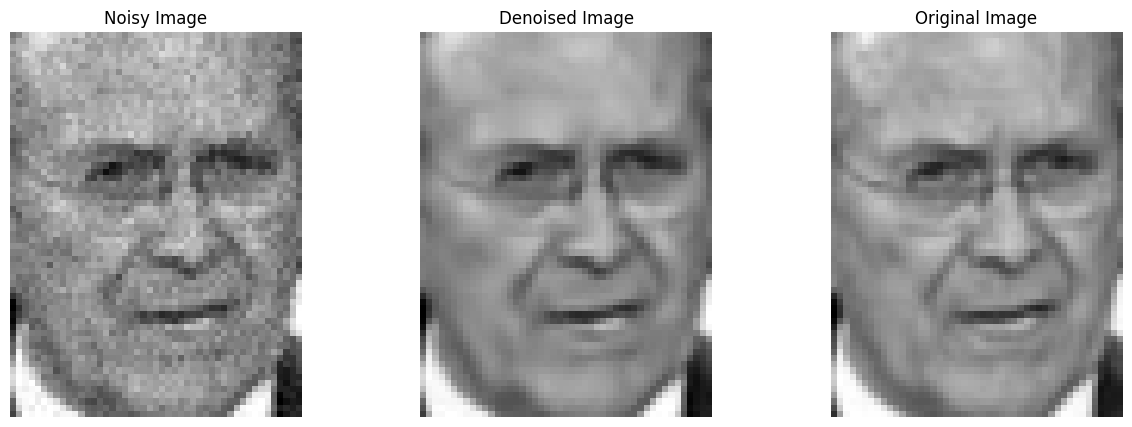

In [12]:
idx = 10

# Denoise one image
cnn.eval()
with torch.no_grad():
    # Take a blurred image
    blurred = add_channel(img_noisy[idx]).unsqueeze(0).to(device)
    # Predict noise and subtract from blurred (keep on GPU)
    noise_pred = cnn(blurred)
    denoised = torch.clamp(blurred - noise_pred, 0, 1).cpu().squeeze()

# Visualize
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_noisy[idx], cmap='gray')
plt.title("Noisy Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised Image")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_grayscale[idx], cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()